# Import thư viện + Load data

In [1]:
import os
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
def read_parquet_by_type(train_path: str):
    # Lấy tất cả các file parquet trong thư mục
    files = [os.path.join(train_path, f) for f in os.listdir(train_path) if f.endswith('.parquet')]
    
    # Phân loại các file theo loại tên
    user_chunk_files = [file for file in files if 'user_chunk' in file]
    purchase_history_chunk_files = [file for file in files if 'purchase_history_daily_chunk' in file]
    item_chunk_files = [file for file in files if 'item_chunk' in file]
    
    # Đọc các file riêng biệt thành DataFrame
    user_chunk_df = pl.concat([pl.read_parquet(file) for file in user_chunk_files]) if user_chunk_files else None
    purchase_history_chunk_df = pl.concat([pl.read_parquet(file) for file in purchase_history_chunk_files]) if purchase_history_chunk_files else None
    item_chunk_df = pl.concat([pl.read_parquet(file) for file in item_chunk_files]) if item_chunk_files else None
    
    # Trả về một dictionary chứa các DataFrame
    return {
        "user_chunk": user_chunk_df,
        "purchase_history_chunk": purchase_history_chunk_df,
        "item_chunk": item_chunk_df
    }

In [75]:
data = read_parquet_by_type("C:/Users/tncn2/Downloads/recommendation dataset")

history_df = data["purchase_history_chunk"]
# user_df = data["user_chunk"]
# item_df = data["item_chunk"]

# Task 1: Loại bỏ các cột mà nhóm nghĩ là không cần thiết.

In [40]:
history_df.head()

timestamp,user_id,item_id,event_type,event_value,price,date_key,quantity,customer_id,created_date,updated_date,channel,payment,location,discount,is_deleted
i64,str,str,str,"decimal[38,4]","decimal[38,4]",i32,i32,i32,datetime[μs],datetime[μs],str,str,i32,"decimal[38,4]",bool
1735064221,"""ca12702ddf55acaa9fb767e10faaa6…","""7115000000004""","""Purchase""",1.0000,49000.0000,20241224,1,5254214,2024-12-24 18:17:01.027,2024-12-24 18:20:09.453,"""In-Store""","""VietQR""",656,0.0000,false
1735068481,"""54314ce86269f4849f9a4c3fc85d94…","""0029130000030""","""Purchase""",1.0000,69000.0000,20241224,1,7573232,2024-12-24 19:28:01.870,2024-12-24 19:28:01.870,"""In-Store""","""Tiền mặt""",143,0.0000,false
1735069843,"""4799de4022b58689b2b9fb37122479…","""3496000000053""","""Purchase""",2.0000,75000.0000,20241224,2,8187418,2024-12-24 19:50:43.760,2024-12-24 19:50:43.760,"""In-Store""","""MoMo""",213,0.0000,false
1735069779,"""4799de4022b58689b2b9fb37122479…","""2700000000002""","""Purchase""",2.0000,58500.0000,20241224,2,8187418,2024-12-24 19:49:39.223,2024-12-24 19:49:39.223,"""In-Store""","""MoMo""",213,13000.0000,false
1735379373,"""3b2423f730815273dfd6f6220b0c5c…","""0029110000036""","""Purchase""",1.0000,89000.0000,20241228,1,6931560,2024-12-28 09:49:33.780,2024-12-28 10:28:49.413,"""Android""","""MoMo""",590,10000.0000,false


Như đã làm ở bước EDA trước:

- "event_type" chỉ có duy nhất một giá trị là "Purchase"
- "is_deleted" chỉ có duy nhất một giá trị là "false"

Hai cột này là bất biến, không mang lại thông tin phân biệt cho mô hình, vì vậy tôi loại bỏ khỏi features để giảm nhiễu, giảm chiều dữ liệu và tiết kiệm chi phí tính toán.

In [76]:
cols_to_drop = ["event_type", "is_deleted"]
history_df = history_df.drop([c for c in cols_to_drop if c in history_df.columns])

# TASK 2: Xử lý Outlier, Xử lý NULL

## Price

In [9]:
price_np = history_df["price"].cast(pl.Float64).to_numpy()

# Bước 2: Tính các giá trị phân vị (quartile)
Q1 = np.percentile(price_np, 25)
Q3 = np.percentile(price_np, 75)
IQR = Q3 - Q1

# Bước 3: Tính giới hạn phát hiện outlier
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Bước 4: Lọc ra các giá trị outlier
outliers_iqr_price = history_df.filter(
    (pl.col("price").cast(pl.Float64) < lower_bound) |
    (pl.col("price").cast(pl.Float64) > upper_bound)
)

# Bước 5: In kết quả thống kê
print("Thống kê IQR cho cột 'price'")
print(f"Q1 (25%): {Q1:,.2f}")
print(f"Q3 (75%): {Q3:,.2f}")
print(f"IQR (Q3 - Q1): {IQR:,.2f}")
print(f"Ngưỡng dưới (Lower bound): {lower_bound:,.2f}")
print(f"Ngưỡng trên (Upper bound): {upper_bound:,.2f}")
print(f"Số lượng outlier: {outliers_iqr_price.height:,}")
print(f"Tỉ lệ outlier: {outliers_iqr_price.height / history_df.height:.2%}")

Thống kê IQR cho cột 'price'
Q1 (25%): 48,316.39
Q3 (75%): 244,000.00
IQR (Q3 - Q1): 195,683.61
Ngưỡng dưới (Lower bound): -245,209.02
Ngưỡng trên (Upper bound): 537,525.41
Số lượng outlier: 2,307,238
Tỉ lệ outlier: 6.46%


Ta dùng IQR với k = 3 cho cột price để phát hiện và “chặn đuôi” (winsorize) outlier theo toàn cục: tính Q1, Q3 ⇒ IQR = Q3−Q1, đặt ngưỡng [Q1−3·IQR, Q3+3·IQR]. 

Điểm nằm ngoài khoảng được gắn cờ is_outlier và clip về biên để tạo price_clip. 

Đồng thời tạo log_price = log1p(price) nhằm ổn định phân phối (giảm lệch phải).

 Cách này giữ lại tương tác cho mô hình khuyến nghị nhưng hạn chế tác động của giá trị cực trị.

In [77]:
k = 3.0
q = history_df.select([
    pl.col("price").quantile(0.25).alias("q1"),
    pl.col("price").quantile(0.75).alias("q3"),
])
q1, q3 = q.row(0); iqr = q3 - q1
lo = q1 - k*iqr; hi = q3 + k*iqr 

df_iqr3 = history_df.with_columns([
    ( (pl.col("price") < lo) | (pl.col("price") > hi) ).alias("is_outlier"),
    pl.col("price").clip(lo, hi).alias("price_clip"),
    pl.col("price").log1p().alias("log_price"),
])

In [78]:
# import os
# (1) Tính ngưỡng IQR (k=3) cho price
k = 3.0
x = pl.col("price").cast(pl.Float64, strict=False)

q = history_df.select([
    x.quantile(0.25).alias("q1"),
    x.quantile(0.75).alias("q3"),
])
q1, q3 = q.row(0)
iqr = float(q3 - q1)
lower = float(q1 - k*iqr)
upper = float(q3 + k*iqr)

# (2) Gắn cờ outlier, clip, tạo log_price
history_df_iqr3 = (
    history_df
    .with_columns([
        x.alias("price_f"),
        ((x < lower) | (x > upper)).alias("is_outlier"),
        x.clip(lower, upper).alias("price_clip"),
        x.log1p().alias("log_price"),
    ])
)

# (3) In nhanh các chỉ số kiểm tra
total = history_df_iqr3.select(pl.len()).item()
n_out = history_df_iqr3.select(pl.col("is_outlier").sum()).item()
pct_out = 100.0 * n_out / total if total else 0.0

impact = history_df_iqr3.select([
    pl.mean("price_f").alias("mean_before"),
    pl.median("price_f").alias("median_before"),
    pl.std("price_f").alias("std_before"),
    pl.mean("price_clip").alias("mean_after"),
    pl.median("price_clip").alias("median_after"),
    pl.std("price_clip").alias("std_after"),
    (pl.col("price_f") <= 0).sum().alias("n_le_zero"),
])

print("\n=== IQR bounds (k=3) ===")
print(f"Q1: {q1:,.2f} | Q3: {q3:,.2f} | IQR: {iqr:,.2f}")
print(f"Lower: {lower:,.2f} | Upper: {upper:,.2f}")
print(f"Outliers: {n_out:,} / {total:,}  ({pct_out:.2f}%)")

print("\n=== Impact before/after clip ===")
print(impact)

# (4) Xem vài outlier lớn nhất để sanity-check
top_outliers = (
    history_df_iqr3
    .filter(pl.col("is_outlier"))
    .select(["price_f", "price_clip"])
    .sort("price_f", descending=True)
    .head(10)
)
print("\n=== Top 10 outliers by original price ===")
print(top_outliers)

# # (5) (Tuỳ chọn) Lưu báo cáo nhỏ ra CSV
# outdir = "./data/history-chunk/stats"
# os.makedirs(outdir, exist_ok=True)
# pl.DataFrame({
#     "k": [k], "q1": [q1], "q3": [q3], "iqr": [iqr],
#     "lower": [lower], "upper": [upper],
#     "total": [total], "n_outliers": [n_out], "pct_outliers": [pct_out],
# }).write_csv(os.path.join(outdir, "price_iqr3_bounds.csv"))
# impact.write_csv(os.path.join(outdir, "price_iqr3_impact.csv"))
# top_outliers.write_csv(os.path.join(outdir, "price_iqr3_top_outliers.csv"))



=== IQR bounds (k=3) ===
Q1: 48,316.39 | Q3: 244,000.00 | IQR: 195,683.61
Lower: -538,734.43 | Upper: 831,050.83
Outliers: 339,552 / 35,729,825  (0.95%)

=== Impact before/after clip ===
shape: (1, 7)
┌──────────────┬──────────────┬──────────────┬─────────────┬─────────────┬─────────────┬───────────┐
│ mean_before  ┆ median_befor ┆ std_before   ┆ mean_after  ┆ median_afte ┆ std_after   ┆ n_le_zero │
│ ---          ┆ e            ┆ ---          ┆ ---         ┆ r           ┆ ---         ┆ ---       │
│ f64          ┆ ---          ┆ f64          ┆ f64         ┆ ---         ┆ f64         ┆ u32       │
│              ┆ f64          ┆              ┆             ┆ f64         ┆             ┆           │
╞══════════════╪══════════════╪══════════════╪═════════════╪═════════════╪═════════════╪═══════════╡
│ 169188.74249 ┆ 87000.0      ┆ 195539.88976 ┆ 166677.1419 ┆ 87000.0     ┆ 179646.4441 ┆ 0         │
│ 4            ┆              ┆              ┆ 1           ┆             ┆ 49          ┆   

In [45]:
history_df_iqr3.head()

timestamp,user_id,item_id,event_value,price,date_key,quantity,customer_id,created_date,updated_date,channel,payment,location,discount,price_f,is_outlier,price_clip,log_price
i64,str,str,"decimal[38,4]","decimal[38,4]",i32,i32,i32,datetime[μs],datetime[μs],str,str,i32,"decimal[38,4]",f64,bool,f64,f64
1735064221,"""ca12702ddf55acaa9fb767e10faaa6…","""7115000000004""",1.0000,49000.0000,20241224,1,5254214,2024-12-24 18:17:01.027,2024-12-24 18:20:09.453,"""In-Store""","""VietQR""",656,0.0000,49000.0,false,49000.0,10.799596
1735068481,"""54314ce86269f4849f9a4c3fc85d94…","""0029130000030""",1.0000,69000.0000,20241224,1,7573232,2024-12-24 19:28:01.870,2024-12-24 19:28:01.870,"""In-Store""","""Tiền mặt""",143,0.0000,69000.0,false,69000.0,11.141876
1735069843,"""4799de4022b58689b2b9fb37122479…","""3496000000053""",2.0000,75000.0000,20241224,2,8187418,2024-12-24 19:50:43.760,2024-12-24 19:50:43.760,"""In-Store""","""MoMo""",213,0.0000,75000.0,false,75000.0,11.225257
1735069779,"""4799de4022b58689b2b9fb37122479…","""2700000000002""",2.0000,58500.0000,20241224,2,8187418,2024-12-24 19:49:39.223,2024-12-24 19:49:39.223,"""In-Store""","""MoMo""",213,13000.0000,58500.0,false,58500.0,10.976799
1735379373,"""3b2423f730815273dfd6f6220b0c5c…","""0029110000036""",1.0000,89000.0000,20241228,1,6931560,2024-12-28 09:49:33.780,2024-12-28 10:28:49.413,"""Android""","""MoMo""",590,10000.0000,89000.0,false,89000.0,11.396403


In [109]:
history_df = history_df_iqr3.drop("is_outlier","price_f","price")
history_df = history_df.rename({"price_clip": "price"})

In [110]:
history_df.head()

timestamp,user_id,item_id,event_value,date_key,quantity,customer_id,created_date,updated_date,channel,payment,location,discount,price,log_price
i64,str,str,"decimal[38,4]",i32,i32,i32,datetime[μs],datetime[μs],str,str,i32,"decimal[38,4]",f64,f64
1735064221,"""ca12702ddf55acaa9fb767e10faaa6…","""7115000000004""",1.0000,20241224,1,5254214,2024-12-24 18:17:01.027,2024-12-24 18:20:09.453,"""In-Store""","""VietQR""",656,0.0000,49000.0,10.799596
1735068481,"""54314ce86269f4849f9a4c3fc85d94…","""0029130000030""",1.0000,20241224,1,7573232,2024-12-24 19:28:01.870,2024-12-24 19:28:01.870,"""In-Store""","""Tiền mặt""",143,0.0000,69000.0,11.141876
1735069843,"""4799de4022b58689b2b9fb37122479…","""3496000000053""",2.0000,20241224,2,8187418,2024-12-24 19:50:43.760,2024-12-24 19:50:43.760,"""In-Store""","""MoMo""",213,0.0000,75000.0,11.225257
1735069779,"""4799de4022b58689b2b9fb37122479…","""2700000000002""",2.0000,20241224,2,8187418,2024-12-24 19:49:39.223,2024-12-24 19:49:39.223,"""In-Store""","""MoMo""",213,13000.0000,58500.0,10.976799
1735379373,"""3b2423f730815273dfd6f6220b0c5c…","""0029110000036""",1.0000,20241228,1,6931560,2024-12-28 09:49:33.780,2024-12-28 10:28:49.413,"""Android""","""MoMo""",590,10000.0000,89000.0,11.396403


## Discount

**Dùng discount rate thay vì discount (số tiền)**
- Scale-invariant: 50k trên món 100k = 50% nhưng trên 3 triệu ≈ 1.7%. Tỷ lệ phản ánh tác động thật hơn số tiền tuyệt đối.
- Người dùng phản ứng theo % giảm; đặc trưng dễ hiểu và ổn định hơn theo thời gian.
- Dễ xử lý outlier: giới hạn tự nhiên trong [0,1], cắt đuôi phải rõ ràng.


**Xử lý**
- Vì price là giá sau giảm, tỉ lệ giảm giá được tính theo tổng giá gốc theo dòng: list_total = price*quantity + discount. 
- Chúng tôi không lưu list_total mà chỉ dùng để tính discount_rate = discount / list_total.
- Sau đó, đuôi phải của discount_rate được clip tại min(𝑝99,85%) (nhưng không dưới 50%) để loại bỏ ngoại lai cực trị.

In [111]:
# Ép kiểu & làm sạch discount âm -> 0
df = history_df.with_columns([
    pl.col("price").cast(pl.Float64).alias("price_f"),       # giá NET / đơn vị
    pl.col("quantity").cast(pl.Float64).alias("qty"),
    pl.when(pl.col("discount").is_null() | (pl.col("discount") < 0))
      .then(0.0).otherwise(pl.col("discount").cast(pl.Float64)).alias("discount_f"),
])

# list_total = price*quantity + discount  (giá gốc theo dòng)
list_total = (pl.col("price_f") * pl.col("qty")) + pl.col("discount_f")

# discount_rate đúng định nghĩa khi price là NET
df = df.with_columns([
    (pl.col("discount_f") > 0).alias("is_discount"),
    pl.when(list_total > 0)
      .then(pl.col("discount_f") / list_total)
      .otherwise(0.0)
      .alias("discount_rate_raw")
])

# Cap đuôi phải cho discount_rate (>0): cap = min(p99, 0.85) nhưng >= 0.50
pos = df.filter(pl.col("discount_rate_raw") > 0)
p99 = pos.select(pl.col("discount_rate_raw").quantile(0.99)).item() if pos.height else 0.0
CAP = min(max(p99, 0.50), 0.85)

# Dùng when/then để cap (không cần clip_min)
df = df.with_columns([
    pl.when(pl.col("discount_rate_raw") < 0).then(0.0)
      .when(pl.col("discount_rate_raw") > CAP).then(pl.lit(CAP))
      .otherwise(pl.col("discount_rate_raw"))
      .alias("discount_rate"),
    (pl.col("discount_rate_raw") > CAP).alias("is_discount_outlier")
]).drop(["discount_rate_raw"])

# Thống kê kiểm tra nhanh
check = df.select([
    (pl.col("is_discount").cast(pl.Float64).mean()*100).round(2).alias("pct_has_discount"),
    pl.col("discount_rate").quantile(0.95).alias("rate_p95"),
    pl.col("discount_rate").quantile(0.99).alias("rate_p99"),
    pl.col("discount_rate").max().alias("max_after_cap"),
    pl.len().alias("n_rows"),
    pl.col("is_discount_outlier").sum().alias("n_outlier_flag")
]).with_columns(
    (pl.col("n_outlier_flag")*100/pl.col("n_rows")).round(2).alias("pct_outlier_flag")
)

df = df.drop(["price_f"])

print(f"CAP dùng cho discount_rate: {CAP:.2%}")
print(check)


CAP dùng cho discount_rate: 70.09%
shape: (1, 7)
┌────────────────┬──────────┬──────────┬───────────────┬──────────┬────────────────┬───────────────┐
│ pct_has_discou ┆ rate_p95 ┆ rate_p99 ┆ max_after_cap ┆ n_rows   ┆ n_outlier_flag ┆ pct_outlier_f │
│ nt             ┆ ---      ┆ ---      ┆ ---           ┆ ---      ┆ ---            ┆ lag           │
│ ---            ┆ f64      ┆ f64      ┆ f64           ┆ u32      ┆ u32            ┆ ---           │
│ f64            ┆          ┆          ┆               ┆          ┆                ┆ f64           │
╞════════════════╪══════════╪══════════╪═══════════════╪══════════╪════════════════╪═══════════════╡
│ 40.27          ┆ 0.353562 ┆ 0.51353  ┆ 0.700885      ┆ 35729825 ┆ 143868         ┆ 0.4           │
└────────────────┴──────────┴──────────┴───────────────┴──────────┴────────────────┴───────────────┘


In [122]:
history_df = df.drop("qty","discount_f","is_discount", "is_discount_outlier","discount")

In [113]:
history_df.head()

timestamp,user_id,item_id,event_value,date_key,quantity,customer_id,created_date,updated_date,channel,payment,location,price,log_price,discount_rate
i64,str,str,"decimal[38,4]",i32,i32,i32,datetime[μs],datetime[μs],str,str,i32,f64,f64,f64
1735064221,"""ca12702ddf55acaa9fb767e10faaa6…","""7115000000004""",1.0000,20241224,1,5254214,2024-12-24 18:17:01.027,2024-12-24 18:20:09.453,"""In-Store""","""VietQR""",656,49000.0,10.799596,0.0
1735068481,"""54314ce86269f4849f9a4c3fc85d94…","""0029130000030""",1.0000,20241224,1,7573232,2024-12-24 19:28:01.870,2024-12-24 19:28:01.870,"""In-Store""","""Tiền mặt""",143,69000.0,11.141876,0.0
1735069843,"""4799de4022b58689b2b9fb37122479…","""3496000000053""",2.0000,20241224,2,8187418,2024-12-24 19:50:43.760,2024-12-24 19:50:43.760,"""In-Store""","""MoMo""",213,75000.0,11.225257,0.0
1735069779,"""4799de4022b58689b2b9fb37122479…","""2700000000002""",2.0000,20241224,2,8187418,2024-12-24 19:49:39.223,2024-12-24 19:49:39.223,"""In-Store""","""MoMo""",213,58500.0,10.976799,0.1
1735379373,"""3b2423f730815273dfd6f6220b0c5c…","""0029110000036""",1.0000,20241228,1,6931560,2024-12-28 09:49:33.780,2024-12-28 10:28:49.413,"""Android""","""MoMo""",590,89000.0,11.396403,0.10101


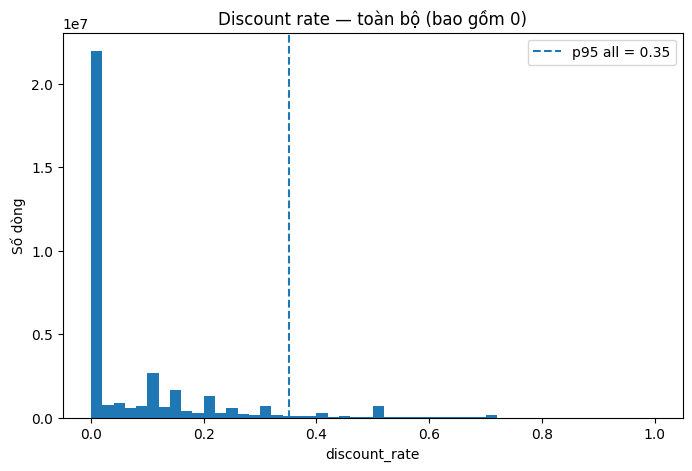

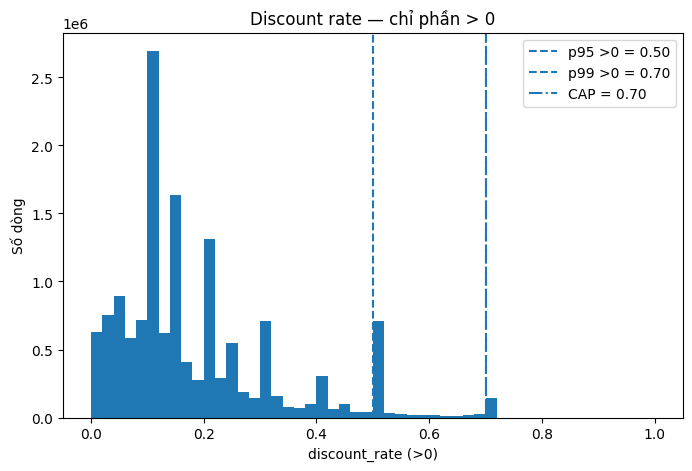

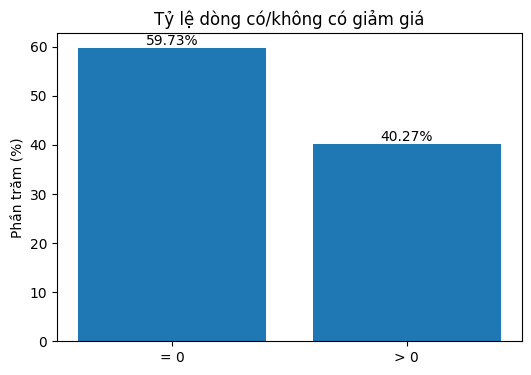

In [18]:
# ==== Visualize discount_rate (Polars + Matplotlib) ====
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

# 0) Chuẩn bị dataframe có discount_rate
# - Nếu đã có df với 'discount_rate' thì dùng luôn
# - Nếu chưa: tính từ history_df (price là NET), không lưu list_total vào df
if 'df' in globals() and isinstance(df, pl.DataFrame) and ('discount_rate' in df.columns):
    base = df
else:
    base = (
        history_df.with_columns([
            pl.col("price").cast(pl.Float64).alias("price_f"),
            pl.col("quantity").cast(pl.Float64).alias("qty"),
            pl.when(pl.col("discount").is_null() | (pl.col("discount") < 0))
              .then(0.0).otherwise(pl.col("discount").cast(pl.Float64)).alias("discount_f"),
        ])
        .with_columns([
            (pl.col("discount_f") > 0).alias("is_discount"),
            pl.when((pl.col("price_f") * pl.col("qty") + pl.col("discount_f")) > 0)
              .then(pl.col("discount_f") / (pl.col("price_f") * pl.col("qty") + pl.col("discount_f")))
              .otherwise(0.0).alias("discount_rate")
        ])
    )

# 1) Thống kê nhanh & CAP (dùng cho đường tham chiếu)
pos = base.filter(pl.col("discount_rate") > 0)
p95_all = base.select(pl.col("discount_rate").quantile(0.95)).item()
p99_pos = pos.select(pl.col("discount_rate").quantile(0.99)).item() if pos.height else 0.0
CAP = min(max(p99_pos, 0.50), 0.85)  # giống pipeline trước

# 2) Histogram toàn bộ (bao gồm 0)
vals_all = base.select(pl.col("discount_rate").cast(pl.Float64)).to_series().to_numpy()
plt.figure(figsize=(8,5))
plt.hist(vals_all, bins=50, range=(0,1))
plt.axvline(p95_all, linestyle="--", linewidth=1.5, label=f"p95 all = {p95_all:.2f}")
plt.title("Discount rate — toàn bộ (bao gồm 0)")
plt.xlabel("discount_rate")
plt.ylabel("Số dòng")
plt.legend()
plt.show()

# 3) Histogram phần > 0 (tập trung vùng hữu ích)
vals_pos = vals_all[vals_all > 0]
if vals_pos.size > 0:
    p95_pos = float(np.quantile(vals_pos, 0.95))
    plt.figure(figsize=(8,5))
    plt.hist(vals_pos, bins=50, range=(0,1))
    plt.axvline(p95_pos, linestyle="--", linewidth=1.5, label=f"p95 >0 = {p95_pos:.2f}")
    plt.axvline(p99_pos, linestyle="--", linewidth=1.5, label=f"p99 >0 = {p99_pos:.2f}")
    plt.axvline(CAP, linestyle="-.", linewidth=1.5, label=f"CAP = {CAP:.2f}")
    plt.title("Discount rate — chỉ phần > 0")
    plt.xlabel("discount_rate (>0)")
    plt.ylabel("Số dòng")
    plt.legend()
    plt.show()

# 4) Biểu đồ cột: tỷ lệ 0 vs >0
share_zero = float((vals_all <= 0).sum()) / vals_all.size if vals_all.size else 0.0
share_pos  = 1.0 - share_zero
plt.figure(figsize=(6,4))
plt.bar(["= 0", "> 0"], [share_zero*100, share_pos*100])
plt.title("Tỷ lệ dòng có/không có giảm giá")
plt.ylabel("Phần trăm (%)")
for i, v in enumerate([share_zero*100, share_pos*100]):
    plt.text(i, v, f"{v:.2f}%", ha="center", va="bottom")
plt.show()


# Task 3: Phân tích tương đồng và xác định xem các thuộc tính tương tự nhau. Từ đó loại bỏ đặc trưng thừa.

Vì "event_type" và "quantity" có giá trị trùng hợp với nhau trên tất cả các dòng (Mismatch rows: 0) nên tôi sẽ loại bỏ "event_value" để tránh trùng thông tin và giảm rủi ro đa cộng tuyến.

In [123]:
mismatch = history_df.select(
    (
        ~(pl.col("event_value").is_null() & pl.col("quantity").is_null())
        & (pl.col("event_value").cast(pl.Float64) != pl.col("quantity").cast(pl.Float64))
    ).sum().alias("mismatch")
).item()

print("Mismatch rows:", mismatch)

if mismatch == 0:
    history_df = history_df.drop("event_value")

Mismatch rows: 0


In [124]:
history_df.head()

timestamp,user_id,item_id,date_key,quantity,customer_id,created_date,updated_date,channel,payment,location,price,log_price,discount_rate
i64,str,str,i32,i32,i32,datetime[μs],datetime[μs],str,str,i32,f64,f64,f64
1735064221,"""ca12702ddf55acaa9fb767e10faaa6…","""7115000000004""",20241224,1,5254214,2024-12-24 18:17:01.027,2024-12-24 18:20:09.453,"""In-Store""","""VietQR""",656,49000.0,10.799596,0.0
1735068481,"""54314ce86269f4849f9a4c3fc85d94…","""0029130000030""",20241224,1,7573232,2024-12-24 19:28:01.870,2024-12-24 19:28:01.870,"""In-Store""","""Tiền mặt""",143,69000.0,11.141876,0.0
1735069843,"""4799de4022b58689b2b9fb37122479…","""3496000000053""",20241224,2,8187418,2024-12-24 19:50:43.760,2024-12-24 19:50:43.760,"""In-Store""","""MoMo""",213,75000.0,11.225257,0.0
1735069779,"""4799de4022b58689b2b9fb37122479…","""2700000000002""",20241224,2,8187418,2024-12-24 19:49:39.223,2024-12-24 19:49:39.223,"""In-Store""","""MoMo""",213,58500.0,10.976799,0.1
1735379373,"""3b2423f730815273dfd6f6220b0c5c…","""0029110000036""",20241228,1,6931560,2024-12-28 09:49:33.780,2024-12-28 10:28:49.413,"""Android""","""MoMo""",590,89000.0,11.396403,0.10101


Chúng tôi đánh giá mối quan hệ giữa hai định danh user_id và customer_id để chọn một khóa chính thống nhất phục vụ join/tổng hợp và hạn chế biến dư thừa trong mô hình.

Kết quả kiểm tra cho thấy hai cột user_id và customer_id mang cùng một lượng thông tin (1-1 theo cả hai chiều).

customer_id là số nguyên (int32), xử lý nhanh và tiết kiệm bộ nhớ hơn chuỗi dài của user_id vì vậy loại bỏ user_id khỏi ma trận đặc trưng.

In [116]:
pairs = history_df.select(["user_id","customer_id"]).drop_nulls().unique()
n_pairs   = pairs.height
n_user    = pairs.select(pl.col("user_id").n_unique()).item()
n_customer= pairs.select(pl.col("customer_id").n_unique()).item()
is_bijection = (n_pairs == n_user == n_customer)

print({"n_pairs": n_pairs, "n_user": n_user, "n_customer": n_customer, "is_bijection": is_bijection})

{'n_pairs': 2442306, 'n_user': 2442306, 'n_customer': 2442306, 'is_bijection': True}


In [125]:
history_df = history_df.drop("user_id")

In [118]:
history_df.head()

timestamp,item_id,date_key,quantity,customer_id,created_date,updated_date,channel,payment,location,price,log_price,discount_rate
i64,str,i32,i32,i32,datetime[μs],datetime[μs],str,str,i32,f64,f64,f64
1735064221,"""7115000000004""",20241224,1,5254214,2024-12-24 18:17:01.027,2024-12-24 18:20:09.453,"""In-Store""","""VietQR""",656,49000.0,10.799596,0.0
1735068481,"""0029130000030""",20241224,1,7573232,2024-12-24 19:28:01.870,2024-12-24 19:28:01.870,"""In-Store""","""Tiền mặt""",143,69000.0,11.141876,0.0
1735069843,"""3496000000053""",20241224,2,8187418,2024-12-24 19:50:43.760,2024-12-24 19:50:43.760,"""In-Store""","""MoMo""",213,75000.0,11.225257,0.0
1735069779,"""2700000000002""",20241224,2,8187418,2024-12-24 19:49:39.223,2024-12-24 19:49:39.223,"""In-Store""","""MoMo""",213,58500.0,10.976799,0.1
1735379373,"""0029110000036""",20241228,1,6931560,2024-12-28 09:49:33.780,2024-12-28 10:28:49.413,"""Android""","""MoMo""",590,89000.0,11.396403,0.10101


Kết quả bên dưới cho thấy date_key gần như đúng bằng phần “ngày” của created_date/updated_date; hai timestamp cũng gần trùng nhau. Sai khác rất nhỏ có thể do ranh giới ngày/timezone hoặc vài dòng ngoại lệ.

Vì vậy loại bỏ date_key khỏi bảng để tránh trùng lặp, dư thừa thông tin.

In [119]:
res = history_df.select([
    # so sánh theo "ngày" (epoch days)
    pl.corr(pl.col("date_key").cast(pl.Int64),
            pl.col("created_date").dt.epoch("d")).alias("r_datekey__created_day"),

    pl.corr(pl.col("date_key").cast(pl.Int64),
            pl.col("updated_date").dt.epoch("d")).alias("r_datekey__updated_day"),

    # mức tương quan giữa 2 mốc thời gian (microseconds)
    pl.corr(pl.col("created_date").dt.epoch("us"),
            pl.col("updated_date").dt.epoch("us")).alias("r_created__updated_ts"),
])
print(res)

shape: (1, 3)
┌────────────────────────┬────────────────────────┬───────────────────────┐
│ r_datekey__created_day ┆ r_datekey__updated_day ┆ r_created__updated_ts │
│ ---                    ┆ ---                    ┆ ---                   │
│ f64                    ┆ f64                    ┆ f64                   │
╞════════════════════════╪════════════════════════╪═══════════════════════╡
│ 0.998299               ┆ 0.998276               ┆ 0.999976              │
└────────────────────────┴────────────────────────┴───────────────────────┘


In [126]:
history_df = history_df.drop("date_key")

**"timestamp"** là epoch giây, tương đương với **"created_date"** (Datetime).

Kiểm tra cho thấy sai số p99 ≈ 0 giây ⇒ timestamp chỉ là biểu diễn khác của cùng thông tin thời gian.

Để tránh trùng lặp và đơn giản hoá pipeline, loại **"timestamp"** khỏi bảng/feature.

In [ ]:
# 1) Nhận diện đơn vị epoch
is_ms = df.select(pl.col("timestamp").max() > 10**12).item()
unit = "ms" if is_ms else "s"

# 2) Đổi epoch -> Datetime (không giả định timezone)
df = df.with_columns(
    pl.from_epoch(pl.col("timestamp"), time_unit=unit).alias("ts_from_epoch")
)

# 3) Kiểm tra trùng với created_date (sai số giây)
cmp = df.select((
    (pl.col("created_date").dt.epoch("s") -
     pl.col("ts_from_epoch").dt.epoch("s")).abs()
).quantile(0.99).alias("p99_abs_diff_s"))
print(cmp)

# 4) Nếu p99_abs_diff_s == 0 (gần như trùng), chọn 1 nguồn duy nhất:
df = (df
      .with_columns(pl.col("created_date").alias("event_ts"))
      .with_columns(pl.col("event_ts").dt.strftime("%Y%m%d").cast(pl.Int32).alias("event_date_key"))
      .drop(["timestamp"])              # drop vì dư thừa
     )

shape: (1, 1)
┌────────────────┐
│ p99_abs_diff_s │
│ ---            │
│ f64            │
╞════════════════╡
│ 0.0            │
└────────────────┘


In [127]:
history_df = history_df.drop("timestamp")
history_df.head()

item_id,quantity,customer_id,created_date,updated_date,channel,payment,location,price,log_price,discount_rate
str,i32,i32,datetime[μs],datetime[μs],str,str,i32,f64,f64,f64
"""7115000000004""",1,5254214,2024-12-24 18:17:01.027,2024-12-24 18:20:09.453,"""In-Store""","""VietQR""",656,49000.0,10.799596,0.0
"""0029130000030""",1,7573232,2024-12-24 19:28:01.870,2024-12-24 19:28:01.870,"""In-Store""","""Tiền mặt""",143,69000.0,11.141876,0.0
"""3496000000053""",2,8187418,2024-12-24 19:50:43.760,2024-12-24 19:50:43.760,"""In-Store""","""MoMo""",213,75000.0,11.225257,0.0
"""2700000000002""",2,8187418,2024-12-24 19:49:39.223,2024-12-24 19:49:39.223,"""In-Store""","""MoMo""",213,58500.0,10.976799,0.1
"""0029110000036""",1,6931560,2024-12-28 09:49:33.780,2024-12-28 10:28:49.413,"""Android""","""MoMo""",590,89000.0,11.396403,0.10101


Phân phối chênh lệch thời gian giữa updated_date và created_date cho thấy 96.34% bản ghi lệch ≤1 phút; chỉ ~0.98% lệch >1 ngày. 

Điều này chứng tỏ updated_date hầu như trùng với thời điểm tạo bản ghi và không bổ sung thông tin cho thời điểm xảy ra sự kiện. 

Do đó, chúng tôi chuẩn hoá dùng created_date làm nguồn thời gian duy nhất; updated_date được loại khỏi ma trận đặc trưng.

In [ ]:
# Chênh lệch phút giữa updated và created
df2 = history_df.with_columns(
    (pl.col("updated_date") - pl.col("created_date"))
      .dt.total_minutes()
      .abs()
      .alias("diff_min")
)

# Gán bucket = nhãn literal, rồi group theo tên cột "diff_bucket"
buckets = (
    df2.with_columns(
        pl.when(pl.col("diff_min") <= 1).then(pl.lit("le_1m"))
         .when(pl.col("diff_min") <= 60).then(pl.lit("1m_1h"))
         .when(pl.col("diff_min") <= 1440).then(pl.lit("1h_1d"))
         .otherwise(pl.lit("gt_1d"))
         .alias("diff_bucket")
    )
    .group_by("diff_bucket").count()
    .sort("diff_bucket")
)

print(buckets)

C:\Users\tncn2\AppData\Local\Temp\ipykernel_11240\2877098970.py:20: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  .group_by("diff_bucket").count()


shape: (4, 2)
┌─────────────┬──────────┐
│ diff_bucket ┆ count    │
│ ---         ┆ ---      │
│ str         ┆ u32      │
╞═════════════╪══════════╡
│ 1h_1d       ┆ 523815   │
│ 1m_1h       ┆ 434449   │
│ gt_1d       ┆ 349745   │
│ le_1m       ┆ 34421816 │
└─────────────┴──────────┘


In [128]:
history_df = history_df.drop("updated_date")
history_df.head()

item_id,quantity,customer_id,created_date,channel,payment,location,price,log_price,discount_rate
str,i32,i32,datetime[μs],str,str,i32,f64,f64,f64
"""7115000000004""",1,5254214,2024-12-24 18:17:01.027,"""In-Store""","""VietQR""",656,49000.0,10.799596,0.0
"""0029130000030""",1,7573232,2024-12-24 19:28:01.870,"""In-Store""","""Tiền mặt""",143,69000.0,11.141876,0.0
"""3496000000053""",2,8187418,2024-12-24 19:50:43.760,"""In-Store""","""MoMo""",213,75000.0,11.225257,0.0
"""2700000000002""",2,8187418,2024-12-24 19:49:39.223,"""In-Store""","""MoMo""",213,58500.0,10.976799,0.1
"""0029110000036""",1,6931560,2024-12-28 09:49:33.780,"""Android""","""MoMo""",590,89000.0,11.396403,0.10101


# Task 4

Trong bài toán khuyến nghị, channel đóng vai trò ngữ cảnh chứ không phải nhãn dự đoán, vì vậy chúng tôi không tái cân bằng phân phối mà tập trung làm gọn và ổn định tín hiệu.

Cụ thể, các giá trị thiếu/không xác định được chuẩn hoá về “Unknown”, còn những kênh có tần suất rất thấp được gộp thành “Other” (giữ Top-K kênh phổ biến, phần còn lại → “Other”).


In [129]:
def keep_topk_other(df: pl.DataFrame, col: str, k: int = 10,
                    other_label: str = "Other", unknown_label: str = "Unknown") -> pl.DataFrame:
    # Chuẩn hoá Unknown nhẹ
    tmp = df.with_columns(
        pl.when(pl.col(col).is_null() | (pl.col(col).cast(pl.Utf8).str.strip_chars()==""))
          .then(pl.lit(unknown_label))
          .otherwise(pl.col(col)).alias(f"{col}_tmp")
    )
    topk = (tmp.group_by(f"{col}_tmp").len()
                .sort("len", descending=True)
                .head(k)
                .select(f"{col}_tmp").to_series().to_list())
    return tmp.with_columns(
        pl.when(pl.col(f"{col}_tmp").is_in(topk))
          .then(pl.col(f"{col}_tmp"))
          .otherwise(pl.lit(other_label))
          .alias(f"{col}_clean")
    ).drop(f"{col}_tmp")

history_df = keep_topk_other(history_df, "channel", k=8)

In [130]:
history_df = history_df.drop("channel")
history_df = history_df.rename({"channel_clean": "channel"})

In [131]:
from pathlib import Path

save_path = Path("history_df_clean.parquet") 

history_df.write_parquet(save_path, compression="zstd", statistics=True)

df_check = pl.read_parquet(save_path)
print({
    "saved_to": str(save_path.resolve()),
    "rows": df_check.height,
    "cols": df_check.width
})

{'saved_to': 'C:\\Users\\tncn2\\OneDrive\\Tài liệu\\CS116EDA\\CS116-EDA-DoAn\\history_df_clean.parquet', 'rows': 35729825, 'cols': 10}


In [132]:
history_df.head()

item_id,quantity,customer_id,created_date,payment,location,price,log_price,discount_rate,channel
str,i32,i32,datetime[μs],str,i32,f64,f64,f64,str
"""7115000000004""",1,5254214,2024-12-24 18:17:01.027,"""VietQR""",656,49000.0,10.799596,0.0,"""In-Store"""
"""0029130000030""",1,7573232,2024-12-24 19:28:01.870,"""Tiền mặt""",143,69000.0,11.141876,0.0,"""In-Store"""
"""3496000000053""",2,8187418,2024-12-24 19:50:43.760,"""MoMo""",213,75000.0,11.225257,0.0,"""In-Store"""
"""2700000000002""",2,8187418,2024-12-24 19:49:39.223,"""MoMo""",213,58500.0,10.976799,0.1,"""In-Store"""
"""0029110000036""",1,6931560,2024-12-28 09:49:33.780,"""MoMo""",590,89000.0,11.396403,0.10101,"""Android"""


# Nháp

In [14]:
# Chọn cửa sổ thời gian (thử 1m, 3m, 5m rồi so sánh)
win = "3m"

df_keyed = history_df.with_columns([
    pl.col("created_date").dt.truncate(win).alias("t_bucket")
])

group_cols = ["user_id", "channel", "payment", "t_bucket"]

order_like_stats = (
    df_keyed
    .group_by(group_cols)
    .agg([
        pl.count().alias("n_lines"),
        pl.n_unique("item_id").alias("n_unique_items"),
        pl.col("quantity").cast(pl.Float64).sum().alias("total_qty"),
        (pl.col("price").cast(pl.Float64) * pl.col("quantity").cast(pl.Float64)).sum().alias("revenue_raw"),
    ])
    .with_columns((pl.col("n_unique_items") > 1).alias("is_multi_product"))
)

summary = order_like_stats.select([
    pl.col("is_multi_product").mean().alias("share_multi_product"),
    pl.col("is_multi_product").sum().alias("num_multi_product_groups"),
    pl.len().alias("num_groups"),
])

print(summary)    


C:\Users\tncn2\AppData\Local\Temp\ipykernel_2076\3459166743.py:14: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("n_lines"),


shape: (1, 3)
┌─────────────────────┬──────────────────────────┬────────────┐
│ share_multi_product ┆ num_multi_product_groups ┆ num_groups │
│ ---                 ┆ ---                      ┆ ---        │
│ f64                 ┆ u32                      ┆ u32        │
╞═════════════════════╪══════════════════════════╪════════════╡
│ 0.500791            ┆ 7570584                  ┆ 15117252   │
└─────────────────────┴──────────────────────────┴────────────┘
